In [84]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score
from sklearn.model_selection import train_test_split, KFold, cross_val_score
from sklearn.preprocessing import StandardScaler
from sklearn.datasets import load_wine

In [92]:
data = pd.read_csv('wine.csv')

In [93]:
data

,Wine,Alcohol,Malic.acid,Ash,Acl,Mg,Phenols,Flavanoids,Nonflavanoid.phenols,Proanth,Color.int,Hue,OD,Proline
0,1,14.23,1.71,2.43,15.6,127,2.80,3.06,0.28,2.29,5.64,1.04,3.92,1065
1,1,13.20,1.78,2.14,11.2,100,2.65,2.76,0.26,1.28,4.38,1.05,3.40,1050
2,1,13.16,2.36,2.67,18.6,101,2.80,3.24,0.30,2.81,5.68,1.03,3.17,1185
3,1,14.37,1.95,2.50,16.8,113,3.85,3.49,0.24,2.18,7.80,0.86,3.45,1480
4,1,13.24,2.59,2.87,21.0,118,2.80,2.69,0.39,1.82,4.32,1.04,2.93,735
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
173,3,13.71,5.65,2.45,20.5,95,1.68,0.61,0.52,1.06,7.70,0.64,1.74,740
174,3,13.40,3.91,2.48,23.0,102,1.80,0.75,0.43,1.41,7.30,0.70,1.56,750
175,3,13.27,4.28,2.26,20.0,120,1.59,0.69,0.43,1.35,10.20,0.59,1.56,835
176,3,13.17,2.59,2.37,20.0,120,1.65,0.68,0.53,1.46,9.30,0.60,1.62,840


In [94]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 178 entries, 0 to 177
Data columns (total 14 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   Wine                  178 non-null    int64  
 1   Alcohol               178 non-null    float64
 2   Malic.acid            178 non-null    float64
 3   Ash                   178 non-null    float64
 4   Acl                   178 non-null    float64
 5   Mg                    178 non-null    int64  
 6   Phenols               178 non-null    float64
 7   Flavanoids            178 non-null    float64
 8   Nonflavanoid.phenols  178 non-null    float64
 9   Proanth               178 non-null    float64
 10  Color.int             178 non-null    float64
 11  Hue                   178 non-null    float64
 12  OD                    178 non-null    float64
 13  Proline               178 non-null    int64  
dtypes: float64(11), int64(3)
memory usage: 19.6 KB


array([[<Axes: title={'center': 'Wine'}>,
        <Axes: title={'center': 'Alcohol'}>,
        <Axes: title={'center': 'Malic.acid'}>,
        <Axes: title={'center': 'Ash'}>],
       [<Axes: title={'center': 'Acl'}>, <Axes: title={'center': 'Mg'}>,
        <Axes: title={'center': 'Phenols'}>,
        <Axes: title={'center': 'Flavanoids'}>],
       [<Axes: title={'center': 'Nonflavanoid.phenols'}>,
        <Axes: title={'center': 'Proanth'}>,
        <Axes: title={'center': 'Color.int'}>,
        <Axes: title={'center': 'Hue'}>],
       [<Axes: title={'center': 'OD'}>,
        <Axes: title={'center': 'Proline'}>, <Axes: >, <Axes: >]],
      dtype=object)

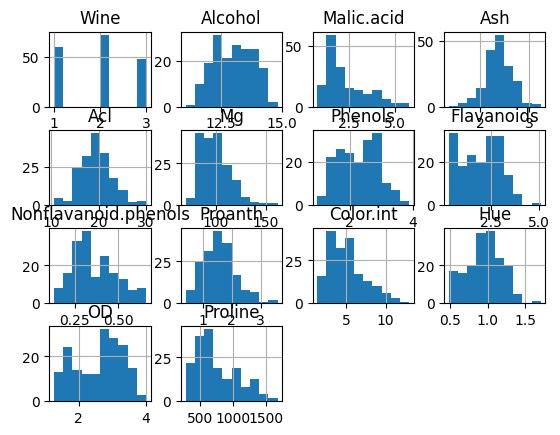

In [95]:
data.hist()

In [96]:
y = data.Wine.values
x = data.drop(columns="Wine")

In [97]:
x_train, x_test, y_train, y_test = train_test_split(x, y, shuffle=True, test_size=0.2)

In [105]:
model = LogisticRegression(max_iter=1000000000)
model.fit(x_train, y_train)
y_pred = model.predict(x_test)

In [106]:
y_pred, y_test

(array([2, 2, 2, 2, 3, 2, 2, 3, 3, 3, 1, 3, 3, 3, 2, 2, 2, 2, 1, 2, 2, 1,
        3, 3, 2, 2, 3, 2, 1, 3, 2, 3, 3, 3, 2, 2]),
 array([2, 2, 2, 2, 3, 2, 2, 3, 3, 3, 1, 3, 3, 3, 2, 2, 2, 2, 1, 2, 2, 1,
        3, 3, 2, 2, 3, 2, 1, 3, 2, 3, 3, 3, 2, 2]))

In [107]:
model.score(x_train, y_train)

0.9929577464788732

In [108]:
accuracy_score(y_test, y_pred)

1.0

In [109]:
scores = cross_val_score(model, x, y, cv=5)

In [110]:
scores.mean()

np.float64(0.961111111111111)